# Phase 1 — Uji mesin routing
Jalankan semua cell. Seluruh input stasiun, crowd, cuaca dan summary forum di sini **simulasi**. Tidak ada panggilan OpenAI, Ollama, atau MAPID. Hasil optimal mengikuti resolusi grid. Grafik tidak menggambarkan Palmerah.

In [1]:
from pathlib import Path
import sys, json, tempfile
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'backend' / 'jakroute').is_dir()), None)
assert ROOT, 'Buka notebook dari folder paket yang sudah diekstrak lengkap.'
sys.path.insert(0, str(ROOT / 'backend'))
DATA = ROOT / 'backend' / 'data'
from jakroute.providers import load_json
from jakroute.config import Settings


In [2]:
from jakroute.indoor_routing import IndoorRouter
from jakroute.crowd import calculate_area_crowd_weight
site=load_json(DATA/'station_demo.json')
router=IndoorRouter(site)
users=load_json(DATA/'crowd_users.json')['users']
incidents=load_json(DATA/'forum_summary_seed.json')['incidents']
layer=calculate_area_crowd_weight(site['crowd_areas'],users)
layer

{'north': {'weighted_users': 75.0, 'area_m2': 600.0, 'density': 0.125}, 'south': {'weighted_users': 1.4, 'area_m2': 480.0, 'density': 0.0029166666666666664}, 'west': {'weighted_users': 0.0, 'area_m2': 336.0, 'density': 0.0}, 'east': {'weighted_users': 0.0, 'area_m2': 336.0, 'density': 0.0}, 'platform_area': {'weighted_users': 1.0, 'area_m2': 1920.0, 'density': 0.0005208333333333333}}

In [3]:
routes={mode:router.route('entrance_west','platform_1',mode,users=users,incidents=incidents) for mode in ('best_fit','fastest','min_walk')}
for mode,r in routes.items():
 print(mode, {'walking_m':r['walking_m'], 'duration_s':r['duration_s'], 'connectors':r['connectors_used']})
 assert 'escalator_link' not in r['connectors_used']
assert routes['min_walk']['walking_m']<=routes['fastest']['walking_m']
assert routes['fastest']['duration_s']<=routes['min_walk']['duration_s']

best_fit {'walking_m': 76.627, 'duration_s': 78.899, 'connectors': ['stairs_link']}
fastest {'walking_m': 76.627, 'duration_s': 78.899, 'connectors': ['stairs_link']}
min_walk {'walking_m': 68.627, 'duration_s': 102.379, 'connectors': ['elevator_link']}


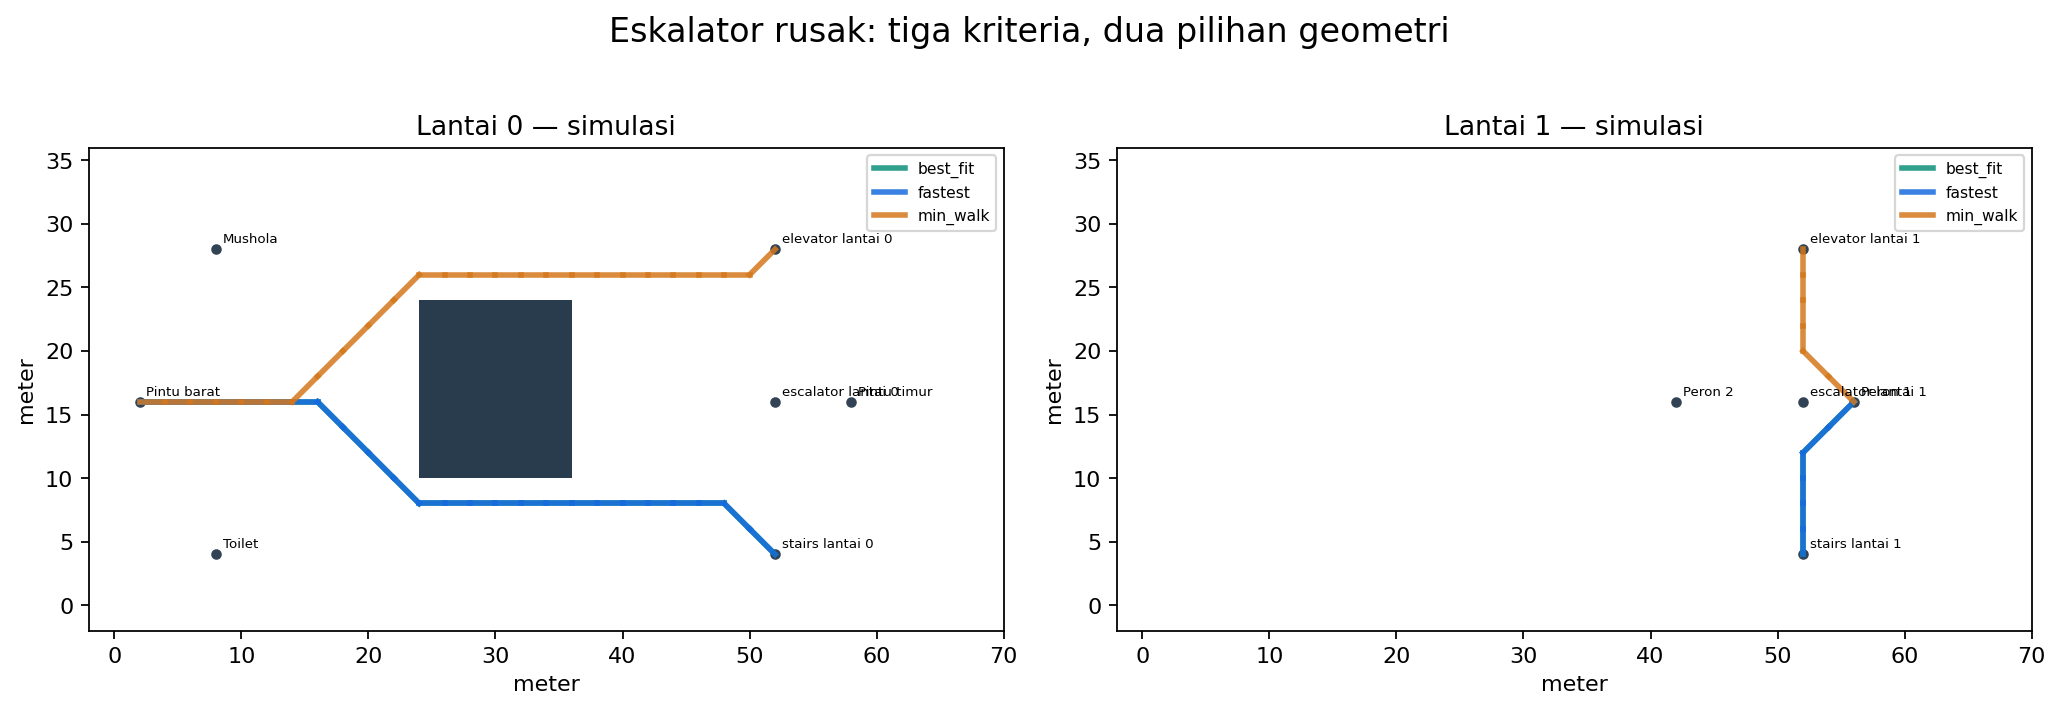

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
colors={'best_fit':'#0b9078','fastest':'#176bdf','min_walk':'#d4771c'}
for floor,ax in enumerate(axes):
 for obstacle in site['floors'][floor]['obstacles']:
  ax.add_patch(Polygon(obstacle[0],facecolor='#293c4e'))
 for mode,r in routes.items():
  segments=[f['properties']['local_xy'] for f in r['geometry']['features'] if f['properties']['floor']==floor]
  for j,seg in enumerate(segments):
   ax.plot([p[0] for p in seg],[p[1] for p in seg],color=colors[mode],alpha=.85,lw=2.5,label=mode if j==0 else None)
 for p in site['places']:
  if p['scope']=='indoor' and p['floor']==floor:
   ax.scatter(*p['xy'],color='#314354',s=14)
   ax.annotate(p['label'],p['xy'],fontsize=6,xytext=(3,3),textcoords='offset points')
 ax.set(xlim=(-2,70),ylim=(-2,36),aspect='equal',title=f'Lantai {floor} — simulasi',xlabel='meter',ylabel='meter')
 ax.legend(fontsize=7)
fig.suptitle('Eskalator rusak: tiga kriteria, dua pilihan geometri',fontsize=15)
fig.tight_layout()
plt.show()

In [5]:
# Larangan tangga + eskalator rusak => lift. Step-free juga menolak eskalator.
for mode in routes:
 r=router.route('entrance_west','platform_1',mode,preferences={'avoid_stairs':True},users=users,incidents=incidents)
 assert r['connectors_used']==['elevator_link']
print('PASS: semua rute menjaga constraint keras.')
from jakroute.providers import create_weather_warning
assert create_weather_warning({'is_raining':True},False)==[]
print(create_weather_warning({'is_raining':True},True))

PASS: semua rute menjaga constraint keras.
['Hujan terdeteksi. Bagian rute luar ruangan berpotensi terkena hujan.']


## Uji pada polygon lampiran asli
File asli berisi 11 polygon Lantai 1 Anggrek. Semua polygon tetap obstacle. Batas luar dan dua titik uji berikut buatan karena sumber tidak menyertakan pintu dan area yang boleh dilalui. Ini hanya bukti algoritma menghindari polygon.

In [6]:
from jakroute.source_demo import build_anggrek_demo
source_router=build_anggrek_demo(DATA)
source_route=source_router.route('test_start','test_goal','min_walk')
from shapely.geometry import LineString,Polygon as SPolygon
for feature in source_route['geometry']['features']:
 line=LineString(feature['properties']['local_xy'])
 assert all(not line.intersects(SPolygon(p[0],p[1:])) for p in source_router.site['floors'][0]['obstacles'])
print('PASS: seluruh segmen menghindari 11 polygon asli; jarak uji',round(source_route['walking_m'],2),'m')

PASS: seluruh segmen menghindari 11 polygon asli; jarak uji 161.8 m


Pengujian lengkap: dari folder `backend`, jalankan `python -m pytest -q`. Test mencakup kepadatan numerik, budget berjalan, fasilitas wajib, kegagalan akses, state forum, dan endpoint.